In [127]:
import pandas as pd
import numpy as np 
import requests
import zipfile
import io
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [128]:
df = pd.read_csv("bank-full.csv", delimiter=";")
df = df[[
    "age",
    "job",
    "marital",
    "education",
    "balance",
    "housing",
    "contact",
    "day",
    "month",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "poutcome",
    "y"
]]
df.isnull().sum() 

age          0
job          0
marital      0
education    0
balance      0
housing      0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [129]:
df.dtypes

age           int64
job          object
marital      object
education    object
balance       int64
housing      object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [130]:
numerical = list(df.dtypes[df.dtypes != "object"].index)
numerical

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [131]:
# df["education"].value_counts()
df["education"].mode()[0]

'secondary'

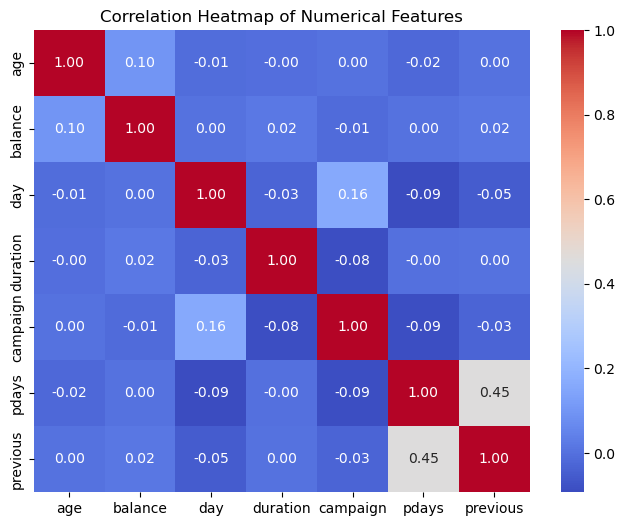

In [132]:
# Ensure plots show inside the notebook
%matplotlib inline  

import seaborn as sns
import matplotlib.pyplot as plt

# Your numeric columns
numerical = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

# Compute correlation matrix
correlation_matrix = df[numerical].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))  # Optional: make the plot larger
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Add a title
plt.title("Correlation Heatmap of Numerical Features")

# Force display
plt.show()


In [133]:
print("`age` and `balance`:\t", correlation_matrix["age"]["balance"].item())
print("`day` and `campaign`:\t", correlation_matrix["day"]["campaign"].item())
print("`day` and `pdays`:\t", correlation_matrix["day"]["pdays"].item())
print("`pdays` and `previous`:\t", correlation_matrix["pdays"]["previous"].item())

`age` and `balance`:	 0.09778273937134807
`day` and `campaign`:	 0.1624902163261922
`day` and `pdays`:	 -0.09304407377294048
`pdays` and `previous`:	 0.4548196354805043


In [134]:
df.y = (df.y == 'yes').astype(int)

In [135]:
from sklearn.model_selection import train_test_split

In [136]:
RANDOM_STATE = 42
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=RANDOM_STATE)
len(df_train), len(df_val), len(df_test)

(27126, 9042, 9043)

In [137]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
y_train = df_train.y.values
y_val = df_val.y.values
y_test = df_test.y.values
del df_train['y']
del df_val['y']
del df_test['y']

In [138]:
categorical = df.columns[df.dtypes == "object"].to_list()
categorical

['job', 'marital', 'education', 'housing', 'contact', 'month', 'poutcome']

In [139]:
from sklearn.metrics import mutual_info_score

In [140]:
def mutual_info_y_score(series):
    return round(mutual_info_score(series, y_train), 2)

In [141]:
mi = df_train[categorical].apply(mutual_info_y_score)
mi.sort_values(ascending=False).index[0]

'month'

In [142]:
mi.sort_values(ascending=False)

month        0.03
poutcome     0.03
job          0.01
housing      0.01
contact      0.01
marital      0.00
education    0.00
dtype: float64

In [143]:
from sklearn.feature_extraction import DictVectorizer

In [144]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [145]:
from sklearn.linear_model import LogisticRegression

In [146]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [147]:
y_pred = model.predict_proba(X_val)[:, 1]
round(((y_pred >= 0.5) == y_val).mean().item(), 2)

0.9

In [148]:
def get_X_train_and_X_val(features):
    dv = DictVectorizer(sparse=False)
    
    train_dict = df_train[features].to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)
    
    val_dict = df_val[features].to_dict(orient='records')
    X_val = dv.transform(val_dict)

    return X_train, X_val

def train_model(X_train):
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model

def validation_accuracy(X_val):
    y_pred = model.predict_proba(X_val)[:, 1]
    return ((y_pred >= 0.5) == y_val).mean().item()

In [149]:
X_train, X_val = get_X_train_and_X_val(categorical + numerical)
model = train_model(X_train)
all_features_y_acc = validation_accuracy(X_val)

In [150]:
for eliminated_feature in ["age", "balance", "marital", "previous"]:
    features = (categorical + numerical)
    features.remove(eliminated_feature)
    X_train, X_val = get_X_train_and_X_val(features)
    model = train_model(X_train)
    acc = validation_accuracy(X_val)
    print(eliminated_feature, ": ", abs(acc - all_features_y_acc))

age :  0.0001105950011059953
balance :  0.00033178500331787486
marital :  0.0006635700066357497
previous :  0.00044238000442375913


In [151]:
def train_model(X_train, C):
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model

In [152]:
C_values = [0.01, 0.1, 1, 10, 100]

X_train, X_val = get_X_train_and_X_val(categorical + numerical)

for C in C_values:
    model = train_model(X_train, C)
    print(C, ": ", round(validation_accuracy(X_val), 3))

0.01 :  0.898
0.1 :  0.9
1 :  0.9
10 :  0.901
100 :  0.901


# Model Evaluation

## Question 1: ROC AUC feature importance

In [153]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

In [154]:
numerical

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [155]:
df_train

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome
0,32,technician,single,tertiary,1100,yes,cellular,11,aug,67,1,-1,0,unknown
1,38,entrepreneur,married,secondary,0,yes,cellular,17,nov,258,1,-1,0,unknown
2,49,blue-collar,married,secondary,3309,yes,cellular,15,may,349,2,-1,0,unknown
3,37,housemaid,married,primary,2410,no,cellular,4,aug,315,1,-1,0,unknown
4,31,self-employed,married,tertiary,3220,no,cellular,26,aug,74,4,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27121,27,services,single,secondary,167,no,cellular,8,jul,606,2,-1,0,unknown
27122,40,technician,single,tertiary,693,no,cellular,30,jan,427,1,-1,0,unknown
27123,54,technician,divorced,secondary,0,yes,unknown,16,may,161,1,-1,0,unknown
27124,25,services,single,secondary,2311,no,cellular,21,jul,1105,2,-1,0,unknown


In [156]:
scores = {}

for feat in numerical:
    score = roc_auc_score(y_train, df_train[feat])
    
    if score < 0.5:
        score = roc_auc_score(y_train, -df_train[feat])    

    scores[feat] = score

scores

{'age': 0.5072154616891561,
 'balance': 0.5868318909887845,
 'day': 0.5250167906149042,
 'duration': 0.8065630842212128,
 'campaign': 0.5682816518810498,
 'pdays': 0.5940897888123242,
 'previous': 0.6034457341820259}

In [157]:
max(scores, key=scores.get)

'duration'

## Question 2: Training the model

In [158]:
dv_ev = DictVectorizer(sparse=False)

train_dict_ev = df_train[categorical + numerical].to_dict(orient='records')
X_train_ev = dv_ev.fit_transform(train_dict_ev)

val_dict_ev = df_val[categorical + numerical].to_dict(orient='records')
X_val_ev = dv_ev.transform(val_dict_ev)

model_ev = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model_ev.fit(X_train_ev, y_train)

y_pred_ev = model_ev.predict_proba(X_val_ev)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_pred_ev)

round(auc(fpr, tpr), 3)

0.91

## Question 3: Precision and Recall

In [159]:
scores = []

thresholds = np.linspace(0, 1, 101)
# thresholds = np.arange(0.0, 1.01, 0.01)

actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

for t in thresholds:
    predicted_positive = (y_pred_ev >= t)
    predicted_negative = (y_pred_ev < t)

    tp = (predicted_positive & actual_positive).sum()
    fp = (predicted_positive & actual_negative).sum()

    fn = (predicted_negative & actual_positive).sum()
    tn = (predicted_negative & actual_negative).sum()

    scores.append((t, tp, tn, fp, fn))

In [160]:
columns = ['threshold', 'tp', 'tn', 'fp', 'fn']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,threshold,tp,tn,fp,fn
0,0.00,1070,0,7972,0
1,0.01,1069,801,7171,1
2,0.02,1067,2086,5886,3
3,0.03,1059,3121,4851,11
4,0.04,1046,4041,3931,24
...,...,...,...,...,...
96,0.96,36,7957,15,1034
97,0.97,33,7959,13,1037
98,0.98,21,7963,9,1049
99,0.99,10,7964,8,1060


In [161]:
df_scores['precision'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores

,threshold,tp,tn,fp,fn,precision,recall
0,0.00,1070,0,7972,0,0.118337,1.000000
1,0.01,1069,801,7171,1,0.129733,0.999065
2,0.02,1067,2086,5886,3,0.153459,0.997196
3,0.03,1059,3121,4851,11,0.179188,0.989720
4,0.04,1046,4041,3931,24,0.210167,0.977570
...,...,...,...,...,...,...,...
96,0.96,36,7957,15,1034,0.705882,0.033645
97,0.97,33,7959,13,1037,0.717391,0.030841
98,0.98,21,7963,9,1049,0.700000,0.019626
99,0.99,10,7964,8,1060,0.555556,0.009346


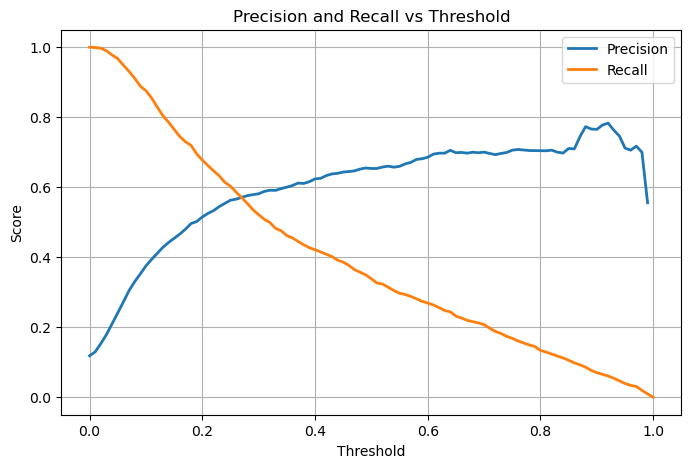

In [162]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(df_scores['threshold'], df_scores['precision'], label='Precision', linewidth=2)
plt.plot(df_scores['threshold'], df_scores['recall'], label='Recall', linewidth=2)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


In [163]:
import numpy as np

# Calculate absolute difference between precision and recall
df_scores['diff'] = abs(df_scores['precision'] - df_scores['recall'])

# Index of the smallest difference
idx = df_scores['diff'].idxmin()

# Extract intersection data
intersection_threshold = df_scores.loc[idx, 'threshold']
precision_at_intersection = df_scores.loc[idx, 'precision']
recall_at_intersection = df_scores.loc[idx, 'recall']

print(f"Intersection at threshold = {intersection_threshold:.3f}")
print(f"Precision = {precision_at_intersection:.3f}, Recall = {recall_at_intersection:.3f}")


Intersection at threshold = 0.270
Precision = 0.571, Recall = 0.570


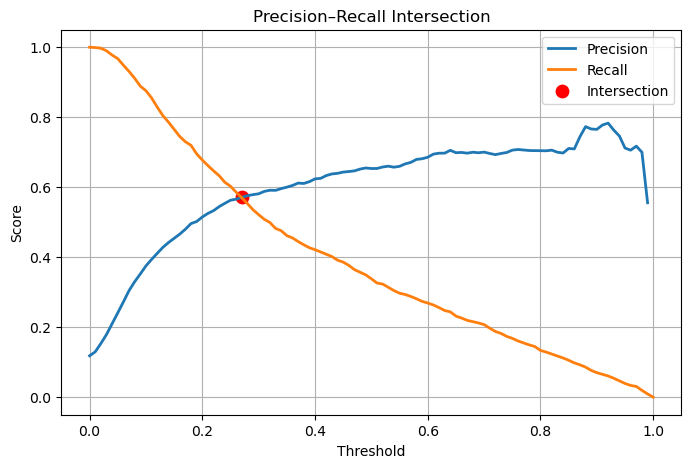

In [164]:
plt.figure(figsize=(8, 5))
plt.plot(df_scores['threshold'], df_scores['precision'], label='Precision', linewidth=2)
plt.plot(df_scores['threshold'], df_scores['recall'], label='Recall', linewidth=2)
plt.scatter(intersection_threshold, precision_at_intersection, color='red', s=80, label='Intersection')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision–Recall Intersection')
plt.legend()
plt.grid(True)
plt.show()


## Question 4: F1 score

In [165]:
df_scores['f1_score'] = (2 * df_scores.precision * df_scores.recall ) / (df_scores.precision + df_scores.recall)
df_scores

,threshold,tp,tn,fp,fn,precision,recall,diff,f1_score
0,0.00,1070,0,7972,0,0.118337,1.000000,0.881663,0.211630
1,0.01,1069,801,7171,1,0.129733,0.999065,0.869332,0.229646
2,0.02,1067,2086,5886,3,0.153459,0.997196,0.843737,0.265985
3,0.03,1059,3121,4851,11,0.179188,0.989720,0.810532,0.303438
4,0.04,1046,4041,3931,24,0.210167,0.977570,0.767403,0.345957
...,...,...,...,...,...,...,...,...,...
96,0.96,36,7957,15,1034,0.705882,0.033645,0.672237,0.064228
97,0.97,33,7959,13,1037,0.717391,0.030841,0.686550,0.059140
98,0.98,21,7963,9,1049,0.700000,0.019626,0.680374,0.038182
99,0.99,10,7964,8,1060,0.555556,0.009346,0.546210,0.018382


In [166]:
df_scores[df_scores.f1_score == df_scores.f1_score.max()].threshold

18    0.18
Name: threshold, dtype: float64

In [167]:
df_scores.loc[df_scores['f1_score'].idxmax()]

threshold       0.180000
tp            770.000000
tn           7190.000000
fp            782.000000
fn            300.000000
precision       0.496134
recall          0.719626
diff            0.223492
f1_score        0.587338
Name: 18, dtype: float64

In [168]:
from sklearn.metrics import f1_score

In [169]:
f1_scores = []

for threshold in thresholds:
    f1 = f1_score(y_val, y_pred_ev > threshold, zero_division=np.nan)
    f1_scores.append(f1)

df_scores["f1"] = f1_scores

In [170]:
df_scores.loc[df_scores['f1'].idxmax()]

threshold       0.180000
tp            770.000000
tn           7190.000000
fp            782.000000
fn            300.000000
precision       0.496134
recall          0.719626
diff            0.223492
f1_score        0.587338
f1              0.587338
Name: 18, dtype: float64

In [171]:
df_scores[df_scores.threshold == 0.23]

,threshold,tp,tn,fp,fn,precision,recall,diff,f1_score,f1
23,0.23,677,7406,566,393,0.54465,0.63271,0.08806,0.585387,0.585387


In [172]:
df_scores

,threshold,tp,tn,fp,fn,precision,recall,diff,f1_score,f1
0,0.00,1070,0,7972,0,0.118337,1.000000,0.881663,0.211630,0.211630
1,0.01,1069,801,7171,1,0.129733,0.999065,0.869332,0.229646,0.229646
2,0.02,1067,2086,5886,3,0.153459,0.997196,0.843737,0.265985,0.265985
3,0.03,1059,3121,4851,11,0.179188,0.989720,0.810532,0.303438,0.303438
4,0.04,1046,4041,3931,24,0.210167,0.977570,0.767403,0.345957,0.345957
...,...,...,...,...,...,...,...,...,...,...
96,0.96,36,7957,15,1034,0.705882,0.033645,0.672237,0.064228,0.064228
97,0.97,33,7959,13,1037,0.717391,0.030841,0.686550,0.059140,0.059140
98,0.98,21,7963,9,1049,0.700000,0.019626,0.680374,0.038182,0.038182
99,0.99,10,7964,8,1060,0.555556,0.009346,0.546210,0.018382,0.018382


In [173]:
def train(df_train, y_train, C):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer()
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model


def predict(df, dv, model):
    dicts = df.to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [174]:
from sklearn.model_selection import KFold

In [176]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.y.values
    y_val = df_val.y.values

    del df_train['y']
    del df_val['y']

    dv, model = train(df_train, y_train, C=1)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

round(np.std(scores).item(), 4)

0.0075

In [177]:
from tqdm.auto import tqdm

In [178]:
for C in [0.000001, 0.001, 1]:
    kfold = KFold(n_splits=5, shuffle=True, random_state=1)
    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
    
        y_train = df_train.y.values
        y_val = df_val.y.values
    
        del df_train['y']
        del df_val['y']
    
        dv, model = train(df_train, y_train, C)
        y_pred = predict(df_val, dv, model)
    
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    print(C, ":\t", round(np.mean(scores), 3), " +- ",  round(np.std(scores), 3))

1e-06 :	 0.695  +-  0.009
0.001 :	 0.861  +-  0.006
1 :	 0.906  +-  0.007
